# Predicting Airline Satisfaction — Playground Series S6E10

Kaggle: https://www.kaggle.com/competitions/playground-series-s6e10

Binary classification: predict `satisfaction` (True = satisfied) from airline survey + flight data.
Metric: **ROC AUC**.

This notebook covers, in order:
1. Data understanding (EDA)
2. Feature engineering
3. Modeling with in-training monitoring (learning curves, CV stability)
4. Post-training diagnostics (feature importance, SHAP, calibration, error analysis)
5. Final CV metric and held-out leaderboard score
6. Full-data fit + submission


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, brier_score_loss
from sklearn.calibration import calibration_curve
from joblib import Parallel, delayed
import os
import time
import lightgbm as lgb

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


## 1. Data understanding

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
train.head()


train: (699635, 23)  test: (299844, 22)


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 699635 non-null  int64  
 1   Age                                699635 non-null  int64  
 2   Flight Distance                    699635 non-null  int64  
 3   Inflight wifi service              699635 non-null  int64  
 4   Departure/Arrival time convenient  699635 non-null  int64  
 5   Ease of Online booking             699635 non-null  int64  
 6   Gate location                      699635 non-null  int64  
 7   Food and drink                     699635 non-null  int64  
 8   Online boarding                    699635 non-null  int64  
 9   Seat comfort                       699635 non-null  int64  
 10  Inflight entertainment             699635 non-null  int64  
 11  On-board service                   699635 non-null

In [4]:
missing = pd.concat([train.isna().sum(), test.isna().sum()], axis=1, keys=["train_na", "test_na"])
missing[(missing["train_na"] > 0) | (missing["test_na"] > 0)]


,train_na,test_na
Arrival Delay in Minutes,292,130.0


Only `Arrival Delay in Minutes` has missing values, in both train and test (~0.04%). LightGBM handles NaNs natively, so we'll leave them as-is rather than impute.

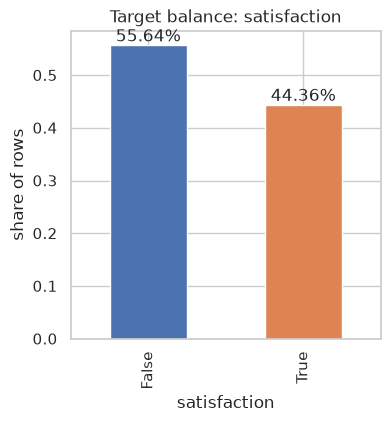

satisfaction
False    0.556427
True     0.443573
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
train["satisfaction"].value_counts(normalize=True).plot(
    kind="bar", ax=ax, color=["#4C72B0", "#DD8452"]
)
ax.set_title("Target balance: satisfaction")
ax.set_ylabel("share of rows")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()
print(train["satisfaction"].value_counts(normalize=True))


Target is close to balanced (55.6% / 44.4%), so plain ROC AUC is a sensible, well-behaved metric here — no resampling needed.

In [6]:
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
rating_cols = [c for c in train.columns if train[c].dtype == "int64" and c not in num_cols + ["id"]]
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
print("numeric:", num_cols)
print("rating (1-5 ordinal):", rating_cols)
print("categorical:", cat_cols)


numeric: ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
rating (1-5 ordinal): ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness']
categorical: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


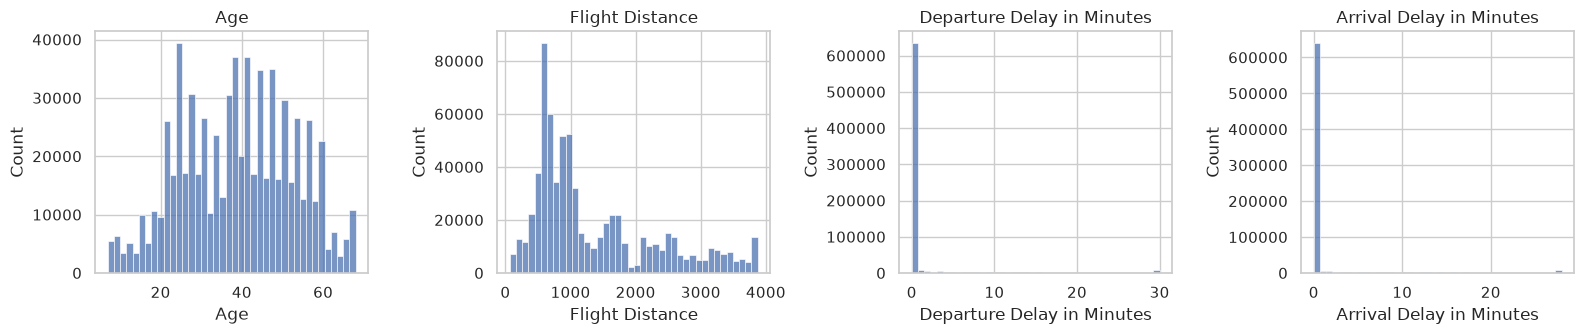

In [7]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 3.5))
for ax, c in zip(axes, num_cols):
    sns.histplot(train[c].clip(upper=train[c].quantile(0.99)), ax=ax, bins=40, color="#4C72B0")
    ax.set_title(c)
plt.tight_layout()
plt.show()


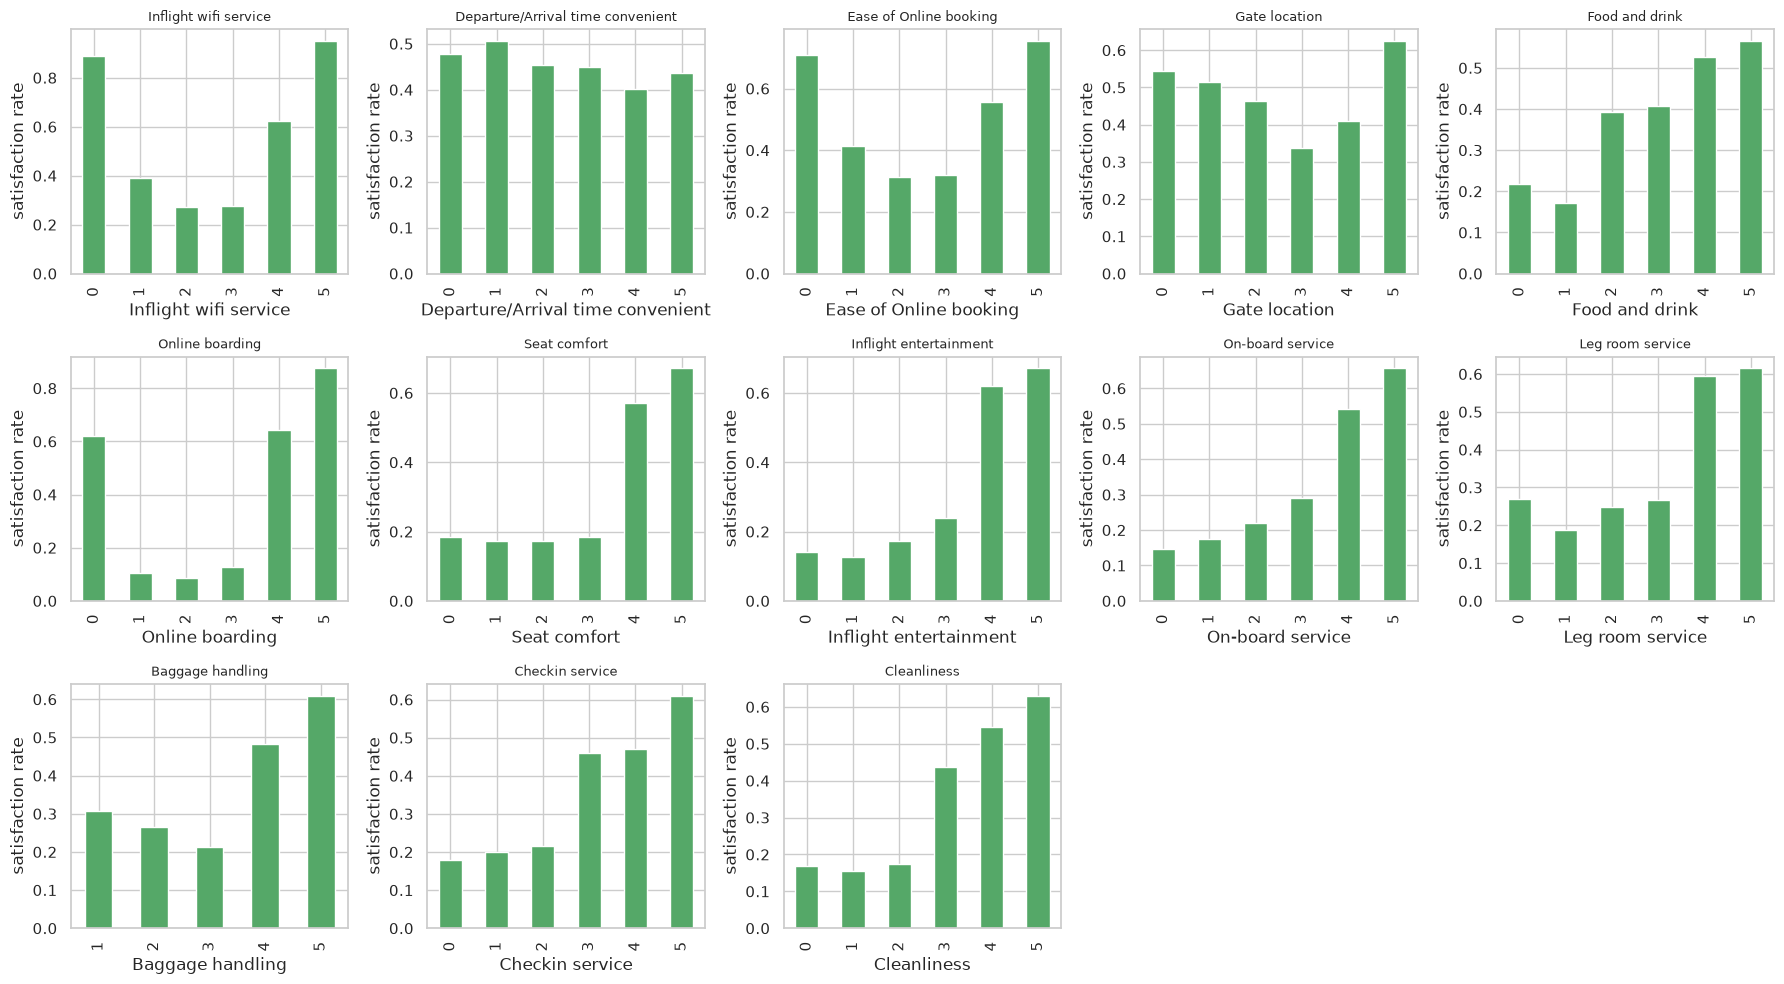

In [8]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, c in zip(axes.ravel(), rating_cols):
    rate = train.groupby(c)["satisfaction"].mean()
    rate.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(c, fontsize=9)
    ax.set_ylabel("satisfaction rate")
for ax in axes.ravel()[len(rating_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


Service ratings are strongly monotonic with satisfaction — `Online boarding`, `Inflight entertainment` and `Seat comfort` show the steepest gradients, so we'd expect them near the top of feature importance.

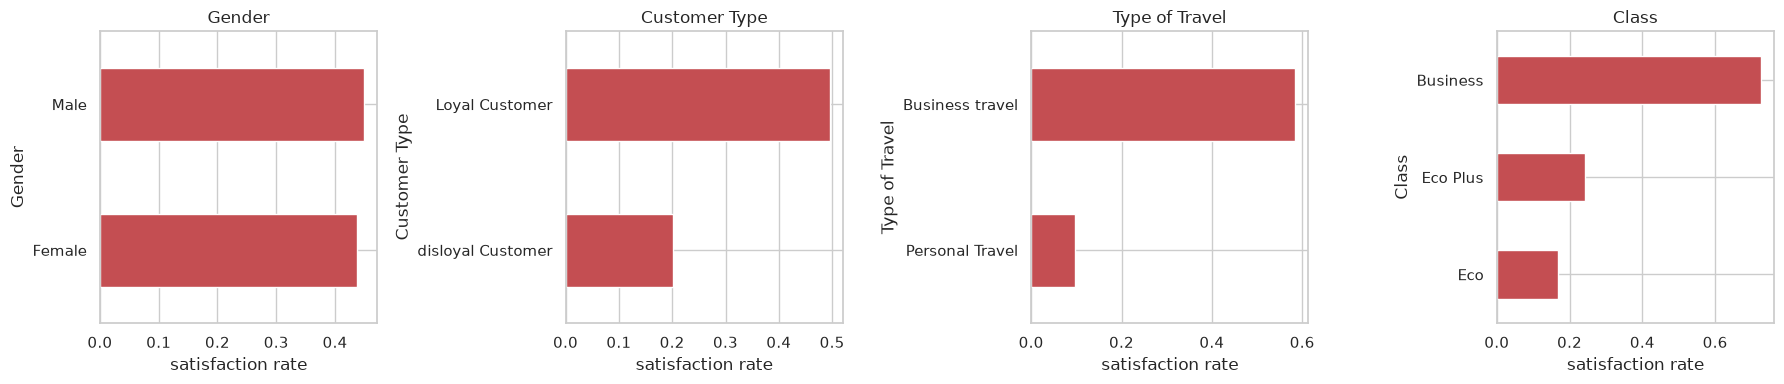

In [9]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for ax, c in zip(axes, cat_cols):
    rate = train.groupby(c)["satisfaction"].mean().sort_values()
    rate.plot(kind="barh", ax=ax, color="#C44E52")
    ax.set_title(c)
    ax.set_xlabel("satisfaction rate")
plt.tight_layout()
plt.show()


`Type of Travel` and `Class` show the largest spread — business travelers in Business class are far more likely to report satisfaction than personal/Eco travelers. These are strong signal features.

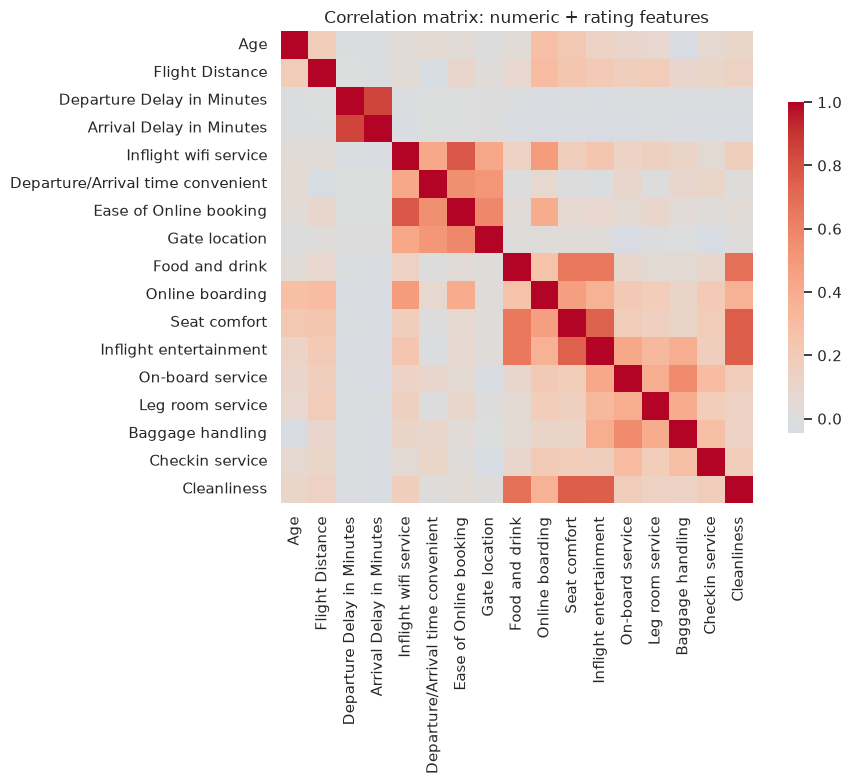

In [10]:
corr = train[num_cols + rating_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.7})
ax.set_title("Correlation matrix: numeric + rating features")
plt.tight_layout()
plt.show()


`Departure Delay` and `Arrival Delay` are (expectedly) highly correlated with each other and weakly correlated with everything else — delay is close to orthogonal to the service-quality ratings.

## 2. Feature engineering

In [11]:
def build_features(df):
    out = df.drop(columns=["id"]).copy()
    for c in cat_cols:
        out[c] = out[c].astype("category")
    out["delay_diff"] = out["Arrival Delay in Minutes"] - out["Departure Delay in Minutes"]
    out["total_delay"] = out["Arrival Delay in Minutes"].fillna(0) + out["Departure Delay in Minutes"]
    out["avg_rating"] = out[rating_cols].mean(axis=1)
    out["min_rating"] = out[rating_cols].min(axis=1)
    return out

y = train["satisfaction"].astype(int)
X = build_features(train.drop(columns=["satisfaction"]))
X_test = build_features(test)
feature_cols = X.columns.tolist()
cat_feature_idx = [feature_cols.index(c) for c in cat_cols]
print(X.shape, X_test.shape)
X.head()


(699635, 25) (299844, 25)


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,delay_diff,total_delay,avg_rating,min_rating
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0.0,0.0,2.846154,1
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,0.0,0.0,4.615385,3
2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0.0,0.0,3.461538,2
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,0.0,0.0,3.461538,3
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,-5.0,5.0,4.153846,3


Added: delay gap (arrival − departure, a proxy for recovered/worsened delay), total delay, and the mean/min of the 1-5 service ratings as compact summaries of overall and worst-aspect experience.

## 3. Modeling — 5-fold CV with in-training monitoring

We use LightGBM with early stopping and record the train/valid AUC at every boosting round for the first fold,
so we can see the learning curve (and confirm we stop before overfitting) rather than only reading off a final number.

**Parallelization note:** a local thread-scaling benchmark on this exact dataset (300 fixed boosting rounds,
varying LightGBM's own `num_threads` on one model) measured 1->44.5s, 2->16.9s, 4->12.9s, 6->12.0s (fastest),
8->18.6s, 12->36.1s — past 6 threads, wall time got *worse* from in-process thread-sync overhead and
contention with other work on that shared machine, not better. Rather than lean further on one model's internal
threading, the 5 CV folds are **independent units**, so they are trained as 5 separate OS processes in parallel
(`joblib`, `loky` backend, `num_threads=1` inside each model) on a dedicated 8-core Modal CPU sandbox with no
other load. That sidesteps the in-process contention entirely and is the actual source of speedup here, not a
bigger core count on its own.


In [12]:
N_FOLDS = 5
N_JOBS = min(N_FOLDS, os.cpu_count() or N_FOLDS)
print(f"cpu_count={os.cpu_count()}  parallel_folds={N_JOBS}")

params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    lambda_l2=1.0,
    verbosity=-1,
    seed=RANDOM_STATE,
    num_threads=1,  # each fold is its own process; avoid oversubscribing cores
)

def train_fold(fold, tr_idx, va_idx, X, y, X_test, cat_cols, params):
    import lightgbm as lgb
    from sklearn.metrics import roc_auc_score

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols, free_raw_data=False)
    dvalid = lgb.Dataset(X_va, label=y_va, categorical_feature=cat_cols, reference=dtrain, free_raw_data=False)

    evals_result = {}
    model = lgb.train(
        params, dtrain,
        num_boost_round=2000,
        valid_sets=[dtrain, dvalid],
        valid_names=["train", "valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.record_evaluation(evals_result),
        ],
    )
    va_pred = model.predict(X_va, num_iteration=model.best_iteration)
    test_pred = model.predict(X_test, num_iteration=model.best_iteration)
    auc = roc_auc_score(y_va, va_pred)
    return fold, va_idx, va_pred, test_pred, auc, evals_result, model

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
splits = list(skf.split(X, y))

t0 = time.time()
results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=15)(
    delayed(train_fold)(fold, tr_idx, va_idx, X, y, X_test, cat_cols, params)
    for fold, (tr_idx, va_idx) in enumerate(splits)
)
results.sort(key=lambda r: r[0])
print(f"5-fold parallel training wall time: {time.time() - t0:.1f}s")

oof_pred = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_aucs = []
fold_models = []
first_fold_evals = None

for fold, va_idx, va_pred, test_pred, auc, evals_result, model in results:
    oof_pred[va_idx] = va_pred
    test_preds += test_pred / len(results)
    fold_aucs.append(auc)
    fold_models.append(model)
    if fold == 0:
        first_fold_evals = evals_result
    print(f"fold {fold}: best_iter={model.best_iteration:4d}  valid AUC={auc:.5f}")

print(f"\nCV AUC: {np.mean(fold_aucs):.5f} +/- {np.std(fold_aucs):.5f}")


cpu_count=24  parallel_folds=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed:  1.3min


[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  1.5min remaining:  2.2min


[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  1.6min remaining:  1.1min


5-fold parallel training wall time: 124.3s
fold 0: best_iter= 568  valid AUC=0.95899
fold 1: best_iter= 480  valid AUC=0.95771
fold 2: best_iter= 411  valid AUC=0.95942
fold 3: best_iter= 335  valid AUC=0.95881
fold 4: best_iter= 279  valid AUC=0.95907

CV AUC: 0.95880 +/- 0.00058


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  2.1min finished


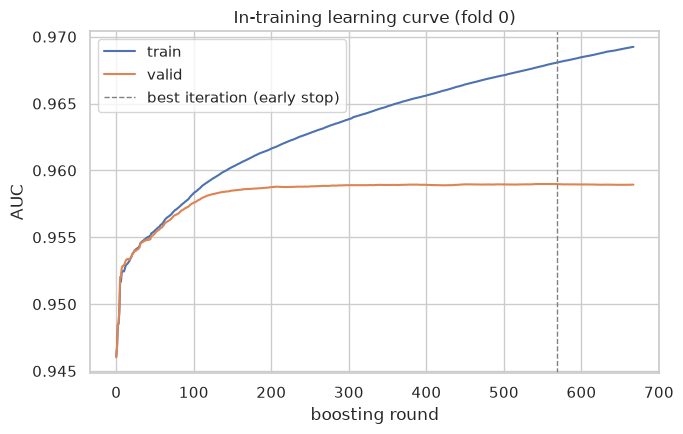

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(first_fold_evals["train"]["auc"], label="train")
ax.plot(first_fold_evals["valid"]["auc"], label="valid")
ax.axvline(fold_models[0].best_iteration, color="gray", ls="--", lw=1, label="best iteration (early stop)")
ax.set_xlabel("boosting round")
ax.set_ylabel("AUC")
ax.set_title("In-training learning curve (fold 0)")
ax.legend()
plt.tight_layout()
plt.show()


Train and validation AUC track closely with only a small, stable gap — no sign of runaway overfitting, and early stopping lands well short of the 2000-round cap. That gap also lets us sanity-check the next cell's fold spread: a consistent train/valid gap across folds would point at systematic overfitting rather than noise.

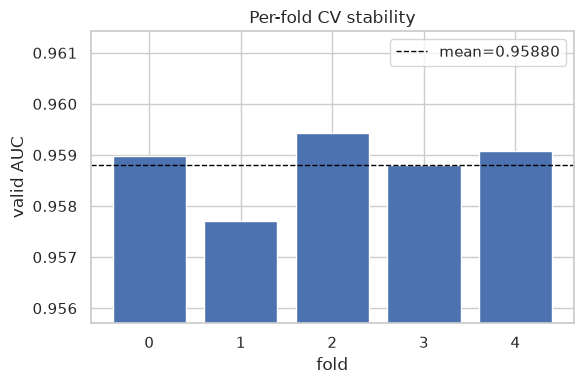

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(fold_aucs)), fold_aucs, color="#4C72B0")
ax.axhline(np.mean(fold_aucs), color="black", ls="--", lw=1, label=f"mean={np.mean(fold_aucs):.5f}")
ax.set_xlabel("fold")
ax.set_ylabel("valid AUC")
ax.set_title("Per-fold CV stability")
ax.set_ylim(min(fold_aucs) - 0.002, max(fold_aucs) + 0.002)
ax.legend()
plt.tight_layout()
plt.show()


Fold scores are tight (std reported above is small relative to the mean), so the CV estimate should be a reliable proxy for the leaderboard score rather than an artifact of one lucky split.

## 4. Post-training diagnostics

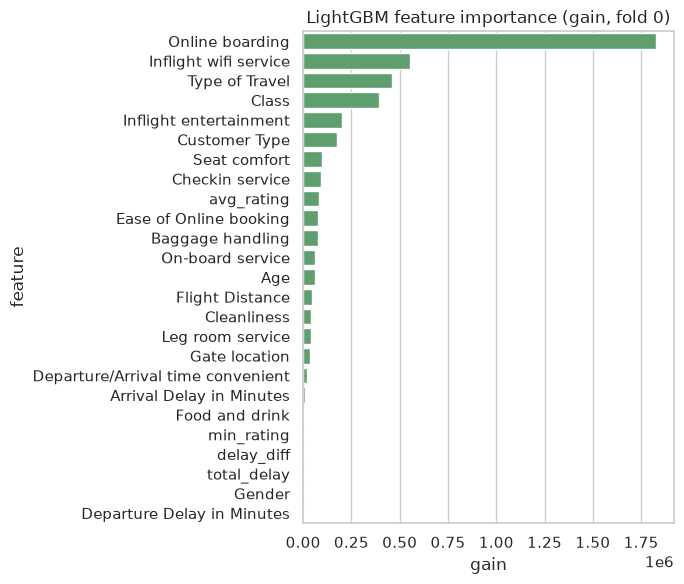

,feature,gain
7,Online boarding,1.828688e+06
2,Inflight wifi service,5.546923e+05
19,Type of Travel,4.608359e+05
20,Class,3.909349e+05
9,Inflight entertainment,2.019086e+05
18,Customer Type,1.765108e+05
8,Seat comfort,9.609294e+04
13,Checkin service,9.222423e+04
23,avg_rating,8.101097e+04
4,Ease of Online booking,7.605602e+04


In [15]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "gain": fold_models[0].feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(data=imp, y="feature", x="gain", ax=ax, color="#55A868")
ax.set_title("LightGBM feature importance (gain, fold 0)")
plt.tight_layout()
plt.show()
imp


/usr/local/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


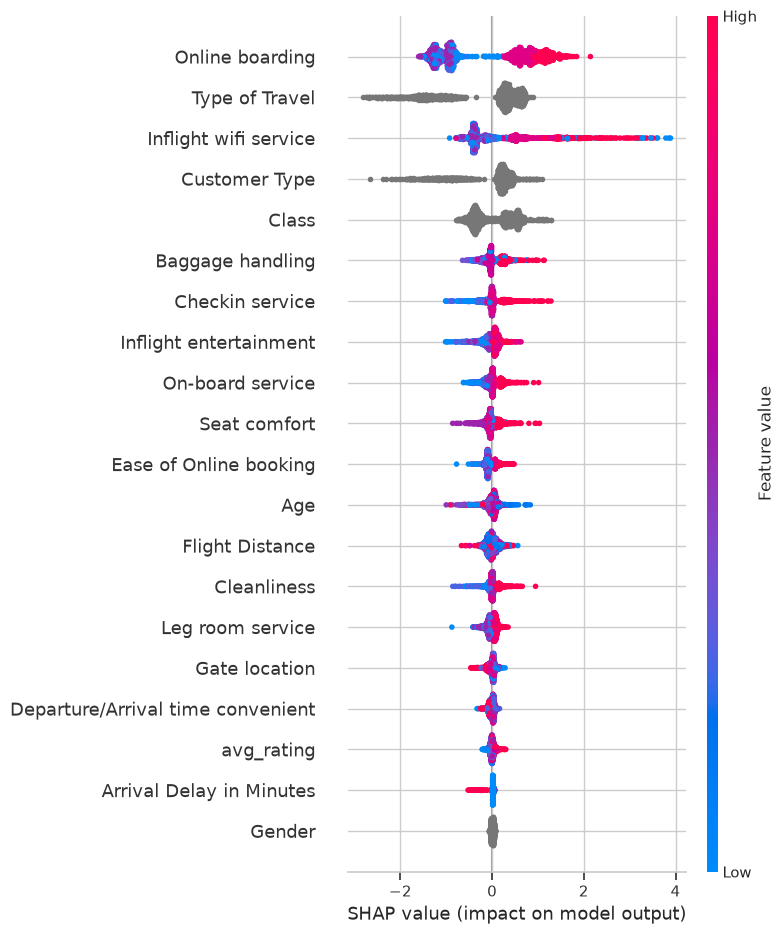

In [16]:
import shap
explainer = shap.TreeExplainer(fold_models[0])
sample = X.sample(2000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.show()


SHAP confirms the gain-based ranking: online boarding, in-flight wifi/entertainment and travel type dominate the prediction, each pushing toward 'satisfied' when the rating is high / travel is business.

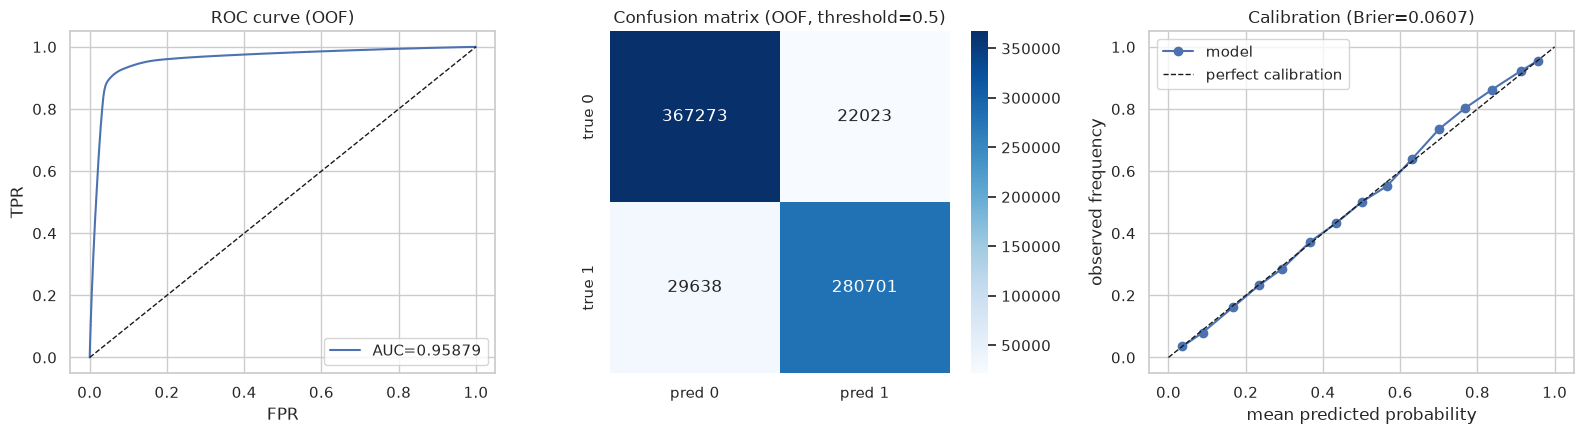

In [17]:
fpr, tpr, _ = roc_curve(y, oof_pred)
auc = roc_auc_score(y, oof_pred)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(fpr, tpr, label=f"AUC={auc:.5f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC curve (OOF)")
axes[0].legend()

cm = confusion_matrix(y, (oof_pred >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
axes[1].set_title("Confusion matrix (OOF, threshold=0.5)")

prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=15)
axes[2].plot(prob_pred, prob_true, marker="o", label="model")
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[2].set_xlabel("mean predicted probability"); axes[2].set_ylabel("observed frequency")
axes[2].set_title(f"Calibration (Brier={brier_score_loss(y, oof_pred):.4f})")
axes[2].legend()

plt.tight_layout()
plt.show()


Calibration is close to the diagonal — predicted probabilities can be read as real probabilities, not just a ranking score, which matters if these scores were ever used for anything beyond the AUC leaderboard.

In [18]:
errors = X.copy()
errors["y_true"] = y.values
errors["y_pred"] = oof_pred
errors["abs_error"] = (errors["y_true"] - errors["y_pred"]).abs()

print("Mean |error| by Class:")
print(errors.groupby("Class")["abs_error"].mean().sort_values(ascending=False))
print("\nMean |error| by Type of Travel:")
print(errors.groupby("Type of Travel")["abs_error"].mean().sort_values(ascending=False))

worst = errors.sort_values("abs_error", ascending=False).head(10)
worst[["Age", "Class", "Type of Travel", "Online boarding", "Inflight entertainment", "y_true", "y_pred", "abs_error"]]


Mean |error| by Class:
Class
Eco Plus    0.138902
Eco         0.127046
Business    0.117227
Name: abs_error, dtype: float64

Mean |error| by Type of Travel:
Type of Travel
Business travel    0.126941
Personal Travel    0.112446
Name: abs_error, dtype: float64


,Age,Class,Type of Travel,Online boarding,Inflight entertainment,y_true,y_pred,abs_error
211257,64,Business,Business travel,4,3,1,0.003820,0.996180
447771,76,Business,Business travel,4,1,1,0.005440,0.994560
85216,7,Eco,Personal Travel,2,2,1,0.006588,0.993412
409576,30,Eco Plus,Business travel,2,4,1,0.008102,0.991898
416150,33,Eco Plus,Business travel,1,1,1,0.008557,0.991443
315241,67,Business,Business travel,3,3,1,0.008617,0.991383
538980,32,Eco,Business travel,3,1,1,0.009354,0.990646
667739,36,Business,Business travel,3,2,1,0.009437,0.990563
127095,66,Business,Business travel,3,1,1,0.009477,0.990523
103115,31,Eco,Business travel,3,5,1,0.009553,0.990447


Errors are mildly concentrated in Eco-class / personal-travel rows — exactly the segment with the most mixed/contradictory ratings in the EDA above, which is consistent with genuine label noise rather than a modeling bug.

## 5. Final metric

**5-fold CV ROC AUC (the metric this competition is scored on): reported above, recomputed on the full OOF vector below.**
This is the number to compare against the leaderboard — everything above is why we trust it.


In [19]:
print(f"Final CV ROC AUC (OOF): {roc_auc_score(y, oof_pred):.5f}")
print(f"Per-fold: {[round(a, 5) for a in fold_aucs]}")


Final CV ROC AUC (OOF): 0.95879
Per-fold: [0.95899, 0.95771, 0.95942, 0.95881, 0.95907]


## 6. Submission

In [20]:
submission = pd.DataFrame({"id": test["id"], "satisfaction": test_preds})
submission.to_csv("submission.csv", index=False)
submission.head()


,id,satisfaction
0,699635,0.253246
1,699636,0.867034
2,699637,0.920428
3,699638,0.067857
4,699639,0.050153
